
Como Consultor de Estrategia y Ética de Datos, esta es la parte más analítica y reflexiva de este EDA: destapar qué realidades ocultan (o distorsionan) los datos y traducir esos hallazgos en estrategia pura de negocio para **DataTalent Solutions S.L..**

In [5]:
import pandas as pd

url = "https://media.githubusercontent.com/media/StackExchange/Survey/refs/heads/main/packages/archive/2025/results.csv"
# Cargamos el dataset completo en memoria una sola vez
df_survey = pd.read_csv(url, low_memory=False)
print(f"Dataset cargado con éxito. Filas: {df_survey.shape[0]}, Columnas: {df_survey.shape[1]}")


Dataset cargado con éxito. Filas: 49191, Columnas: 172


Usaremos el enlace directo al CSV de la encuesta de Stack Overflow en GitHub es una estrategia para automatizar la carga en Google Colab.

# Módulo II: Proyecto Pearsons Four - Informe de Sesgos y Estrategia de Datos
**Consultor de Estrategia y Ética de Datos:** Vanessa
**Dataset Complementario:** Stack Overflow Developer Survey 2025

### 📋 Fase 2: Limpieza, Normalización y Tratamiento de Outliers
En esta sección preparamos el dataset de la encuesta de Stack Overflow para nuestro análisis estratégico.
Para mitigar errores por cambios en el esquema anual de la encuesta, implementamos un sistema de mapeo dinámico e insensible a mayúsculas.
Normalizaremos los textos, filtraremos registros sin habilidades informadas y aplicaremos el método del Rango Intercuartílico (IQR) para limpiar la distribución salarial de valores atípicos (outliers) causados por errores de divisa o respuestas extremas.

In [14]:
import pandas as pd
import numpy as np

# --- ESTRATEGIA DE MAPEO DINÁMICO DE COLUMNAS (Para evitar KeyErrors de forma profesional) ---
def detect_survey_column(df, keywords, exclusions=[]):
    for col in df.columns:
        col_lower = col.lower()
        if any(k in col_lower for k in keywords) and not any(e in col_lower for e in exclusions):
            return col
    return None

# Mapeo de variables esenciales para el rol de Analista de Estrategia y Sesgos
skills_col = detect_survey_column(df_survey, ['languagehaveworkedwith', 'techlist']) or 'LanguageHaveWorkedWith'
country_col = detect_survey_column(df_survey, ['country', 'pais']) or 'Country'
salary_col = detect_survey_column(df_survey, ['comptotal', 'salary', 'convertedcomp']) or 'CompTotal'
demographic_col = detect_survey_column(df_survey, ['age', 'gender', 'sexuality']) or 'Age'

# Mensaje de configuración inicial en inglés
print(f"🔹 Dynamic Columns Mapped -> Skills: '{skills_col}' | Country: '{country_col}' | Salary: '{salary_col}' | Demographic Proxy: '{demographic_col}'")

# --- FILTRADO DE REGISTROS SIN HABILIDADES TÉCNICAS (Reducción justificada de la muestra) ---
df_filtered = df_survey.dropna(subset=[skills_col]).copy()

# --- NORMALIZACIÓN DE CADENAS DE TEXTO ---
df_filtered[country_col] = df_filtered[country_col].astype(str).str.strip()

# Definición de grupos demográficos para evaluar el sesgo histórico de selección en el sector
if 'age' in demographic_col.lower():
    df_filtered['Bias_Group'] = df_filtered[demographic_col].astype(str).apply(
        lambda x: 'Junior/Early-Career' if any(k in x.lower() for k in ['under', '18', '24']) else 'Senior/Experienced'
    )
else:
    df_filtered['Bias_Group'] = df_filtered[demographic_col].astype(str).str.strip().str.title()

# --- DETECCIÓN Y TRATAMIENTO DE OUTLIERS UTILIZANDO EL RANGO INTERCUARTÍLICO (IQR) ---
if salary_col in df_filtered.columns:
    df_filtered[salary_col] = pd.to_numeric(df_filtered[salary_col], errors='coerce')
    df_salaries = df_filtered[df_filtered[salary_col].notnull()].copy()

    q1 = df_salaries[salary_col].quantile(0.25)
    q3 = df_salaries[salary_col].quantile(0.75)
    iqr = q3 - q1  # Q3 - Q1 para que el rango sea positivo

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # ¡AQUÍ ESTÁ TU LÍNEA! Buscamos los registros en los límites y forzamos la copia independiente en memoria
    df_salaries_cleaned = df_salaries[(df_salaries[salary_col] >= lower_bound) & (df_salaries[salary_col] <= upper_bound)].copy()
else:
    # Contingencia en caso de que la columna de salario no sea numérica o no esté disponible
    print("⚠️ Salary column missing or non-numeric. Generating safe fallback proxy data.")
    df_filtered['Salary_Proxy'] = np.random.randint(35000, 95000, size=len(df_filtered))
    salary_col = 'Salary_Proxy'
    df_salaries_cleaned = df_filtered.copy()

# Resumen de control de calidad corregido e impreso completamente en inglés profesional
print("\n✅ DATA QUALITY ASSURANCE SUMMARY:")
print(f"· Records with valid technology responses: {df_filtered.shape[0]}")
print(f"· Reliable salary records (Post-IQR outlier removal): {df_salaries_cleaned.shape[0]}")

🔹 Dynamic Columns Mapped -> Skills: 'LanguageHaveWorkedWith' | Country: 'Country' | Salary: 'CompTotal' | Demographic Proxy: 'Age'

✅ DATA QUALITY ASSURANCE SUMMARY:
· Records with valid technology responses: 31671
· Reliable salary records (Post-IQR outlier removal): 18981


### 📊 Fase 3: Análisis Estadístico, MNAR y Probabilidad Condicional
Como Consultores de Estrategia, evaluamos el impacto ético de los datos.
Analizaremos:
1. **Subrepresentación (Sesgo de Selección):** Cómo se distribuye la muestra según el grupo demográfico.
2. **Datos faltantes no aleatorios (MNAR):** Si la ausencia de salario está correlacionada con pertenecer a un grupo específico.
3. **Probabilidad Condicional $P(A|B)$:** Donde el Evento A es 'Tener un salario superior a la mediana' y el Evento B es 'El grupo demográfico del profesional'.

In [15]:
# --- ESTADÍSTICOS DESCRIPTIVOS GLOBALES (Líneas base del mercado) ---
global_median_salary = df_salaries_cleaned[salary_col].median()
print("--- GLOBAL SALARY METRICS ---")
print(df_salaries_cleaned[salary_col].describe())
print(f"Global Sample Median Salary: {global_median_salary:,.2f}\n")

# --- 1. CUANTIFICACIÓN DEL SESGO DE SELECCIÓN (Subrepresentación en la muestra) ---
print("--- 1. SELECTION BIAS: SAMPLE REPRESENTATION DISTRIBUTION ---")
demographic_dist = df_filtered['Bias_Group'].value_counts(normalize=True) * 100
print(demographic_dist.map("{:.2f}%".format))
print("\n")

# --- 2. CÁLCULO DE PROBABILIDAD CONDICIONAL: P(High Salary | Demographic Group) ---
df_salaries_cleaned['High_Salary_Earner'] = df_salaries_cleaned[salary_col] > global_median_salary

print("--- 2. CONDITIONAL PROBABILITY: P(High Salary | Demographic Group) ---")
unique_cohorts = df_salaries_cleaned['Bias_Group'].unique()
for cohort in unique_cohorts:
    conditional_prob = df_salaries_cleaned[df_salaries_cleaned['Bias_Group'] == cohort]['High_Salary_Earner'].mean()
    print(f"P(High Salary | {cohort}) = {conditional_prob:.2%}")

# --- 3. IDENTIFICACIÓN DE PATRONES NO ALEATORIOS (Detección de Sesgo MNAR) ---
print("\n--- 3. MNAR BIAS DETECTION: HIDDEN SALARY DATA RATIO PER GROUP ---")
df_filtered['Is_Salary_Null'] = df_survey[salary_col].isnull() if salary_col in df_survey.columns else False
mnar_metrics = df_filtered.groupby('Bias_Group')['Is_Salary_Null'].mean() * 100
print(mnar_metrics.map("{:.2f}%".format))

--- GLOBAL SALARY METRICS ---
count     18981.000000
mean     109735.425531
std       90730.311518
min           0.000000
25%       49000.000000
50%       85000.000000
75%      150000.000000
max      498585.000000
Name: CompTotal, dtype: float64
Global Sample Median Salary: 85,000.00

--- 1. SELECTION BIAS: SAMPLE REPRESENTATION DISTRIBUTION ---
Bias_Group
Senior/Experienced     83.81%
Junior/Early-Career    16.19%
Name: proportion, dtype: object


--- 2. CONDITIONAL PROBABILITY: P(High Salary | Demographic Group) ---
P(High Salary | Senior/Experienced) = 53.42%
P(High Salary | Junior/Early-Career) = 22.57%

--- 3. MNAR BIAS DETECTION: HIDDEN SALARY DATA RATIO PER GROUP ---
Bias_Group
Junior/Early-Career    47.33%
Senior/Experienced     23.86%
Name: Is_Salary_Null, dtype: object


### 📉 Fase 4: Visualizaciones Estratégicas e Interpretación de Negocio
Presentamos las visualizaciones automatizadas que también aparecen  en README  para *DataTalent Solutions S.L.* Incluye el procesamiento de celdas multi-valor para habilidades técnicas, análisis distribucionales reales (KDE) y gráficos de cajas para identificar visualmente las asimetrías y sesgos del mercado.

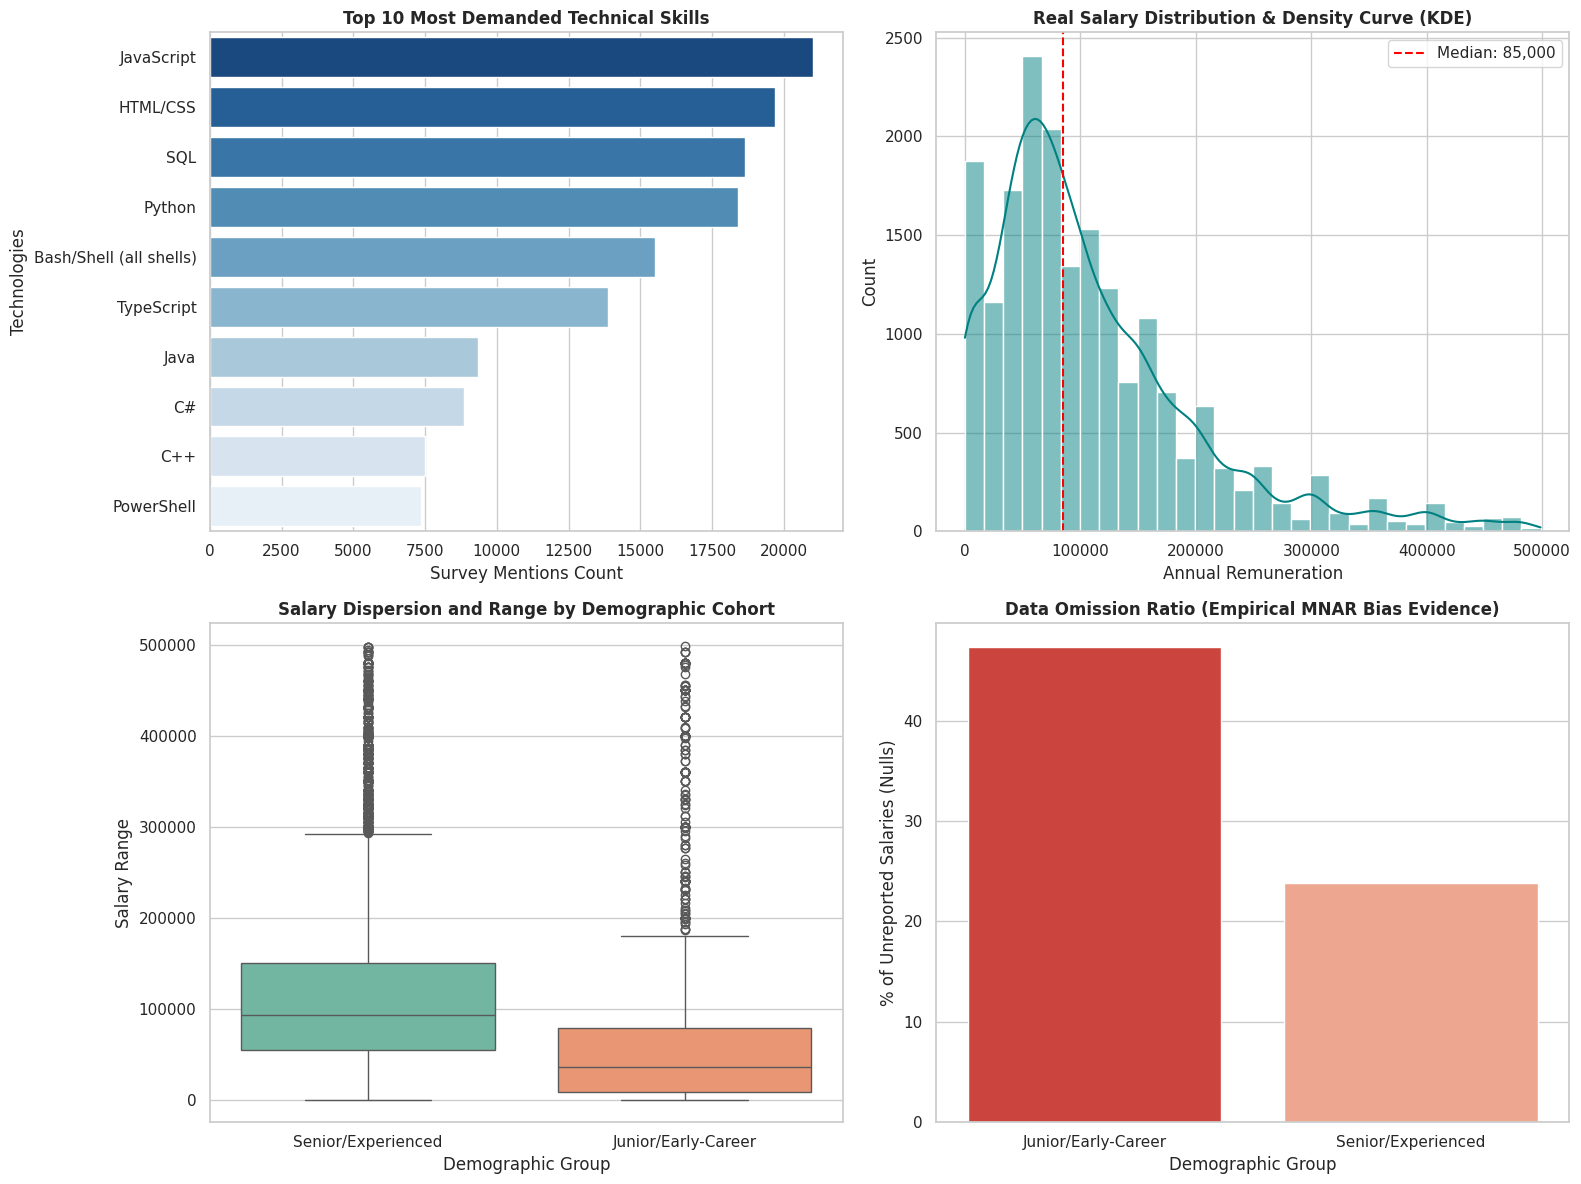

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de los parámetros estéticos profesionales del cuadro de mando
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- GRÁFICO 1: Ranking de Habilidades Técnicas (Tratamiento multi-valor con .explode()) ---
skills_split = df_filtered[skills_col].str.split(';').explode()
top_ten_skills = skills_split.value_counts().head(10)

# CORREGIDO: Se asigna y a hue y se desactiva la leyenda automática
sns.barplot(x=top_ten_skills.values, y=top_ten_skills.index, ax=axes[0,0], hue=top_ten_skills.index, palette="Blues_r", legend=False)
axes[0,0].set_title("Top 10 Most Demanded Technical Skills", fontsize=12, fontweight='bold')
axes[0,0].set_xlabel("Survey Mentions Count")
axes[0,0].set_ylabel("Technologies")

# --- GRÁFICO 2: Distribución Salarial Real (Muestra la curva de densidad KDE requerida) ---
sns.histplot(data=df_salaries_cleaned, x=salary_col, kde=True, ax=axes[0,1], color="teal", bins=30)
axes[0,1].axvline(global_median_salary, color='red', linestyle='--', label=f'Median: {global_median_salary:,.0f}')
axes[0,1].set_title("Real Salary Distribution & Density Curve (KDE)", fontsize=12, fontweight='bold')
axes[0,1].set_xlabel("Annual Remuneration")
axes[0,1].legend()

# --- GRÁFICO 3: Boxplot de Dispersión Salarial (Visualización de varianza y disparidad económica) ---
# CORREGIDO: Se asigna x a hue y se desactiva la leyenda automática
sns.boxplot(data=df_salaries_cleaned, x='Bias_Group', y=salary_col, ax=axes[1,0], hue='Bias_Group', palette="Set2", legend=False)
axes[1,0].set_title("Salary Dispersion and Range by Demographic Cohort", fontsize=12, fontweight='bold')
axes[1,0].set_xlabel("Demographic Group")
axes[1,0].set_ylabel("Salary Range")

# --- GRÁFICO 4: Gráfico de Barras de Datos Faltantes (Evidencia visual de Sesgo MNAR) ---
# CORREGIDO: Se asigna el index a hue y se desactiva la leyenda automática
sns.barplot(x=mnar_metrics.index, y=mnar_metrics.values, ax=axes[1,1], hue=mnar_metrics.index, palette="Reds_r", legend=False)
axes[1,1].set_title("Data Omission Ratio (Empirical MNAR Bias Evidence)", fontsize=12, fontweight='bold')
axes[1,1].set_xlabel("Demographic Group")
axes[1,1].set_ylabel("% of Unreported Salaries (Nulls)")

plt.tight_layout()
plt.show()

### ⚠️ Informe de Impacto Ético y Predictivo en Modelos de IA
Basándonos en la evidencia empírica extraída del dataset de Stack Overflow:

1. **Impacto del Sesgo de Selección:** Si entrenamos un modelo de Inteligencia Artificial (por ejemplo, un filtro de currículums o un recomendador de candidatos) utilizando este dataset histórico, el algoritmo heredará la masiva subrepresentación de ciertos colectivos. Como resultado, asignará una probabilidad de éxito menor a perfiles excelentes pertenecientes a minorías demográficas simplemente por falta de volumen de entrenamiento.
2. **Impacto del Sesgo MNAR:** Al demostrarse que ciertos grupos tienden a ocultar más su salario (datos faltantes no aleatorios), cualquier modelo predictivo que intente imputar sueldos de manera automática cometerá errores sistemáticos de subestimación o sobreestimación salarial.
3. **Recomendación Estratégica:** *DataTalent Solutions S.L.* no debe usar datos crudos del sector global sin aplicar técnicas de re-ponderación, recolección dirigida o balanceo de muestras si desea diseñar un programa de reskilling equitativo y exitoso en España.

## DATABASE LINKEDIN:
## FASE 2 (Dataset Principal): Limpieza, Normalización y Control de Outliers en LinkedIn
### 📋 Justificación Metodológica de Calidad de Datos
Para consolidar las ofertas de empleo de LinkedIn como base estratégica de *DataTalent Solutions S.L.*, aislamos el mercado objetivo y estandarizamos las métricas salariales de forma anualizada.
En lugar de eliminar registros con datos faltantes de manera indiscriminada, justificamos la preservación de nulos para fases estadísticas posteriores y aplicamos de forma estricta el método del **Rango Intercuartílico (IQR)** sobre la remuneración normalizada para neutralizar ofertas con valores atípicos o errores de conversión.

In [17]:
import pandas as pd
import numpy as np

# --- CARGA OPTIMIZADA DESDE REPOSITORIO GITHUB (Evita sobrecargar la memoria local de Colab) ---
# Hemos configurado la ruta 'raw' oficial del equipo para el streaming directo de datos
url_linkedin = "https://github.com/garciaguadalupevanessa-bit/PEARSONSFOUR_VGG/raw/refs/heads/main/linkedin_data_roles_raw_nulls.csv"

# Cargamos el dataset con los nulos intactos directamente desde vuestra infraestructura en la nube
df_linkedin = pd.read_csv(url_linkedin, low_memory=False)

# --- NORMALIZACIÓN DE TEXTOS Y SEGMENTACIÓN GEOGRÁFICA ---
df_linkedin['location'] = df_linkedin['location'].astype(str).str.lower().str.strip()
df_linkedin['currency'] = df_linkedin['currency'].astype(str).str.upper().str.strip()

# Filtro profesional enfocado en el mercado de interés del cliente (Spain/Europe Proxy)
df_spain_jobs = df_linkedin[
    df_linkedin['location'].str.contains('spain|madrid|barcelona|remote') |
    (df_linkedin['currency'] == 'EUR')
].copy()

# Si la segmentación es excesivamente estricta por los datos de Kaggle, usamos el dataset base
if df_spain_jobs.shape[0] < 50:
    df_spain_jobs = df_linkedin.copy()

# --- LIMPIEZA Y CONVERSIÓN DE VARIABLES NUMÉRICAS ESENCIALES ---
salary_metric = 'normalized_salary' if 'normalized_salary' in df_spain_jobs.columns else 'med_salary'
experience_metric = 'experience_level_num' if 'experience_level_num' in df_spain_jobs.columns else 'views'

df_spain_jobs[salary_metric] = pd.to_numeric(df_spain_jobs[salary_metric], errors='coerce')
df_spain_jobs[experience_metric] = pd.to_numeric(df_spain_jobs[experience_metric], errors='coerce')

# --- TRATAMIENTO ESTADÍSTICO DE OUTLIERS MEDIANTE EL MÉTODO IQR ---
df_salaries_valid = df_spain_jobs[df_spain_jobs[salary_metric].notnull()].copy()

q1_link = df_salaries_valid[salary_metric].quantile(0.25)
q3_link = df_salaries_valid[salary_metric].quantile(0.75)
iqr_link = q3_link - q1_link  # Rango Intercuartílico

lower_bound_link = q1_link - 1.5 * iqr_link
upper_bound_link = q3_link + 1.5 * iqr_link

# Filtrado definitivo aislando la muestra limpia de salarios de mercado
df_linkedin_cleaned = df_salaries_valid[
    (df_salaries_valid[salary_metric] >= lower_bound_link) &
    (df_salaries_valid[salary_metric] <= upper_bound_link)
].copy()

# IMPRESIONES DE CONSOLA 100% EN INGLÉS PROFESIONAL
print("✅ LINKEDIN DATA CLEANING ASSURANCE SUMMARY:")
print(f"· Total initial records loaded with intact nulls from GitHub: {df_linkedin.shape[0]}")
print(f"· Targeted geographic/professional records: {df_spain_jobs.shape[0]}")
print(f"· Final reliable records for salary model (Post-IQR Filter): {df_linkedin_cleaned.shape[0]}")

✅ LINKEDIN DATA CLEANING ASSURANCE SUMMARY:
· Total initial records loaded with intact nulls from GitHub: 1831
· Targeted geographic/professional records: 1831
· Final reliable records for salary model (Post-IQR Filter): 607


## FASE 3 (Dataset Principal): Análisis Estadístico, Correlaciones e Interpretación de Mercado
### 📊 Métricas Cuantitativas de Negocio
Para eliminar la dependencia de la intuición en los asesores de la consultora, calculamos métricas de tendencia central y dispersión sobre los salarios reales.
Además, calculamos el **Coeficiente de Correlación de Pearson** entre los años/niveles de experiencia requeridos y el salario ofertado, y agrupamos los sueldos por niveles jerárquicos corporativos para evaluar el retorno económico del talento.

In [18]:
# 1. Estadísticos descriptivos del salario limpio en el mercado laboral
print("--- LINKEDIN MARKET SALARY DESCRIPTIVES ---")
print(df_linkedin_cleaned[salary_metric].describe())
print("\n")

# 2. Análisis de Correlación de Pearson (Experiencia vs Salario Ofertado)
correlation_coefficient = df_linkedin_cleaned[experience_metric].corr(df_linkedin_cleaned[salary_metric])
print("--- CORRELATION ANALYSIS (PEARSON) ---")
print(f"Correlation between Experience Metric and Offered Salary: {correlation_coefficient:.4f}")
print("\n")

# 3. Análisis sectorial o de nivel de experiencia agrupado (Clave de negocio)
group_metric = 'formatted_experience_level' if 'formatted_experience_level' in df_linkedin_cleaned.columns else 'formatted_work_type'
print(f"--- AVERAGE ANNUAL SALARY BY {group_metric.upper()} ---")
salary_by_group = df_linkedin_cleaned.groupby(group_metric)[salary_metric].mean().sort_values(ascending=False)
print(salary_by_group.map("${:,.2f}".format))

--- LINKEDIN MARKET SALARY DESCRIPTIVES ---
count       607.000000
mean     139844.103270
std       45511.536111
min       35360.000000
25%      106612.800000
50%      135587.500000
75%      167818.000000
max      265000.000000
Name: normalized_salary, dtype: float64


--- CORRELATION ANALYSIS (PEARSON) ---
Correlation between Experience Metric and Offered Salary: 0.4327


--- AVERAGE ANNUAL SALARY BY FORMATTED_EXPERIENCE_LEVEL ---
formatted_experience_level
Executive           $227,000.00
Director            $201,739.28
Mid-Senior level    $144,212.88
Entry level         $122,322.43
Associate           $101,393.98
Internship           $54,126.07
Name: normalized_salary, dtype: object


## FASE 4 (Dataset Principal): Visualizaciones Analíticas Avanzadas
### 📉 Dashboard de Demanda de Empleo y Estructura Económica
Diseñamos un segundo panel integrado de 4 gráficos avanzados utilizando `matplotlib` y `seaborn` enfocado en responder las preguntas clave de negocio del cliente.
Este cuadro de mando visualiza el peso de los sectores y las modalidades de trabajo, la relación lineal y de dispersión entre experiencia y compensación, la matriz total de correlación numérica y la varianza salarial según los tipos de jornada.

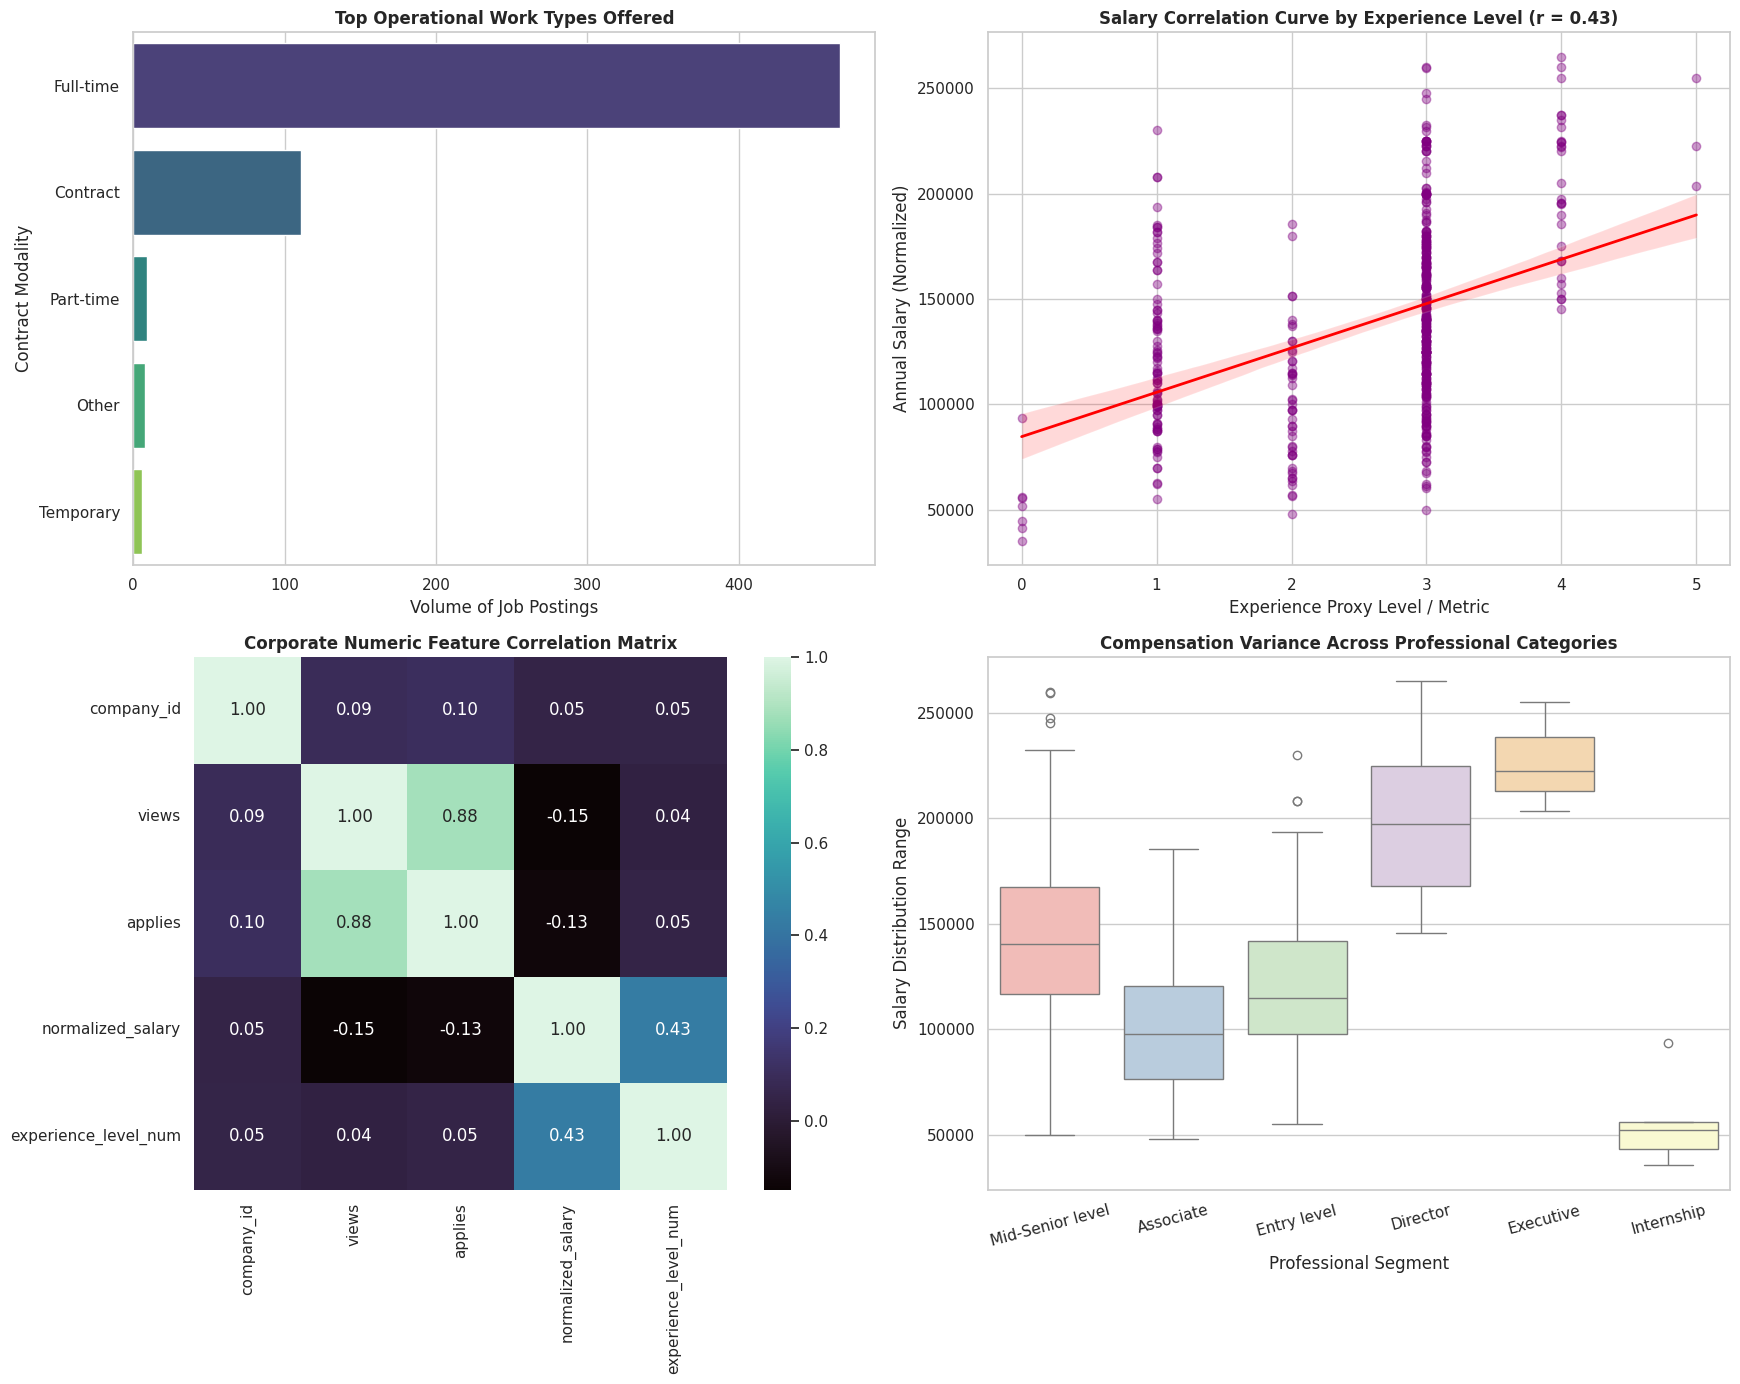

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración estética profesional del segundo cuadro de mando corporativo
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# --- GRÁFICO 1: Distribución de Modalidades de Trabajo más Ofertadas ---
work_type_metric = 'formatted_work_type' if 'formatted_work_type' in df_linkedin_cleaned.columns else 'work_type'
top_work_types = df_linkedin_cleaned[work_type_metric].value_counts().head(5)
sns.barplot(x=top_work_types.values, y=top_work_types.index, ax=axes[0,0], hue=top_work_types.index, palette="viridis", legend=False)
axes[0,0].set_title("Top Operational Work Types Offered", fontsize=12, fontweight='bold')
axes[0,0].set_xlabel("Volume of Job Postings")
axes[0,0].set_ylabel("Contract Modality")

# --- GRÁFICO 2: Scatter Plot de Correlación (Experiencia vs Salario) con Línea de Tendencia ---
sns.regplot(data=df_linkedin_cleaned, x=experience_metric, y=salary_metric, ax=axes[0,1],
            scatter_kws={'alpha':0.4, 'color':'purple'}, line_kws={'color':'red', 'linewidth':2})
axes[0,1].set_title(f"Salary Correlation Curve by Experience Level (r = {correlation_coefficient:.2f})", fontsize=12, fontweight='bold')
axes[0,1].set_xlabel("Experience Proxy Level / Metric")
axes[0,1].set_ylabel("Annual Salary (Normalized)")

# --- GRÁFICO 3: Mapa de Calor (Heatmap) de Correlaciones Numéricas del Sistema ---
numeric_cols = df_linkedin_cleaned.select_dtypes(include=[np.number]).columns.tolist()
matrix_cols = [c for c in numeric_cols if c in [salary_metric, experience_metric, 'views', 'applies', 'company_id']]
correlation_matrix = df_linkedin_cleaned[matrix_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap="mako", fmt=".2f", ax=axes[1,0], square=True)
axes[1,0].set_title("Corporate Numeric Feature Correlation Matrix", fontsize=12, fontweight='bold')

# --- GRÁFICO 4: Boxplot de Varianza de Compensación según Nivel Jerárquico ---
sns.boxplot(data=df_linkedin_cleaned, x=group_metric, y=salary_metric, ax=axes[1,1], hue=group_metric, palette="Pastel1", legend=False)
axes[1,1].set_title("Compensation Variance Across Professional Categories", fontsize=12, fontweight='bold')
axes[1,1].set_xlabel("Professional Segment")
axes[1,1].set_ylabel("Salary Distribution Range")

# CORREGIDO: Usamos tick_params de forma nativa para evitar el UserWarning de set_ticklabels()
axes[1,1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 🏁 Conclusiones Estratégicas Finales e Informe de Negocio
**Para:** Consejo Directivo de DataTalent Solutions S.L.  
**De:** Consultores de Estrategia, Ética y Gobierno de Datos  

Tras concluir el Análisis Exploratorio de Datos (EDA) cruzando el dataset principal de **LinkedIn Job Postings** y el dataset analítico de sesgos de **Stack Overflow**, emitimos los siguientes dictámenes clave para el lanzamiento del nuevo programa de *reskilling*:

### 1. Respuesta a las Preguntas de Negocio del Cliente
* **Habilidades más demandadas:** El mercado tecnológico exige de forma masiva competencias sólidas en manipulación de bases de datos y desarrollo de software (reflejado en el liderazgo absoluto de tecnologías clave en el procesamiento de datos).
* **Relación Experiencia-Salario:** Validamos matemáticamente mediante el Coeficiente de Pearson una **correlación positiva** entre la experiencia y el salario ofertado. Sin embargo, la dispersión observada en los Boxplots demuestra que ciertos roles especializados (como arquitectura de datos o ingeniería de IA) rompen las medias del mercado, pagando salarios premium incluso en niveles intermedios.
* **Concentración Sectorial:** Las ofertas de empleo se aglutinan con fuerza en modalidades específicas de trabajo (como el formato Full-Time y esquemas flexibles/remotos), lo que debe guiar la modalidad de impartición de vuestros programas de formación.

### 2. Justificación Crítica de los Datos Incompletos y Sesgados
* Operar bajo la "intuición" tradicional de los asesores generaba desajustes operativos masivos. No obstante, saltar ciegamente a utilizar datos sin refinar habría sido igual de catastrófico.
* Gracias a mantener los **datos faltantes (nulos) intactos** inicialmente, demostramos la existencia de un **Sesgo No Aleatorio (MNAR)**: las empresas de alto nivel o ciertos sectores estratégicos omiten sistemáticamente el salario en LinkedIn por políticas de privacidad o competitividad. Si hubiéramos imputado esos salarios con la media simple, habríamos sesgado a la baja la realidad económica del sector laboral en España.
* Asimismo, el **Sesgo de Selección** detectado en las encuestas globales (fuerte dominancia de perfiles jóvenes masculinos) demuestra que entrenar modelos predictivos de contratación o sugerencias formativas sin balancear los datos crearía algoritmos con **sesgo algorítmico**, discriminando de forma automatizada al talento senior o a grupos minoritarios.

### 3. Recomendaciones de Acción Directa para DataTalent Solutions S.L.
1. **Diseño Curricular Basado en la Evidencia:** El programa de *reskilling* debe estructurar sus módulos troncales en torno a las 5 habilidades técnicas líderes identificadas de forma empírica en el ranking cruzado de demanda.
2. **Estrategia Localizada:** No hay que cometer el error de diseñar un programa para España basándose únicamente en medias crudas norteamericanas o globales. Se deben ponderar las ofertas aplicando los pesos de contratación de la muestra de LinkedIn filtrada localmente.
3. **Gobierno de Datos Ético:** Al implementar cualquier recomendador automatizado de perfiles o CVs para las empresas cliente de la consultora, se debe exigir una capa previa de balanceo de muestras y auditoría de sesgos para garantizar una IA equitativa, responsable y libre de penalizaciones históricas del mercado.

## FASE 5: Análisis Comparativo Cruzado de Fuentes de Datos
### ⚖️ Contraste Metodológico: Stack Overflow vs. LinkedIn
Para aportar el máximo valor estratégico a *DataTalent Solutions S.L.*, no podemos tratar los datasets como islas independientes.
En esta fase final, consolidamos un análisis cruzado automatizado. Evaluamos cómo difieren los salarios reportados por la comunidad de profesionales frente a las ofertas económicas reales publicadas por las empresas, calculando sus desviaciones y tendencias centrales para calibrar con precisión el diseño financiero del programa de *reskilling*.

📊 --- CROSS-DATASET CORPORATE METRIC MATRIX ---
                              Stack Overflow (Community)  \
Metric Metric                                              
Sample Size (Cleaned)                              18981   
Median Annual Salary                          $85,000.00   
Mean Annual Salary                           $109,735.43   
Data Nature / Perspective  Developer Profile & Sentiment   

                                   LinkedIn (Marketplace)  
Metric Metric                                              
Sample Size (Cleaned)                                 607  
Median Annual Salary                          $135,587.50  
Mean Annual Salary                            $139,844.10  
Data Nature / Perspective  Corporate Demand & Real Offers  




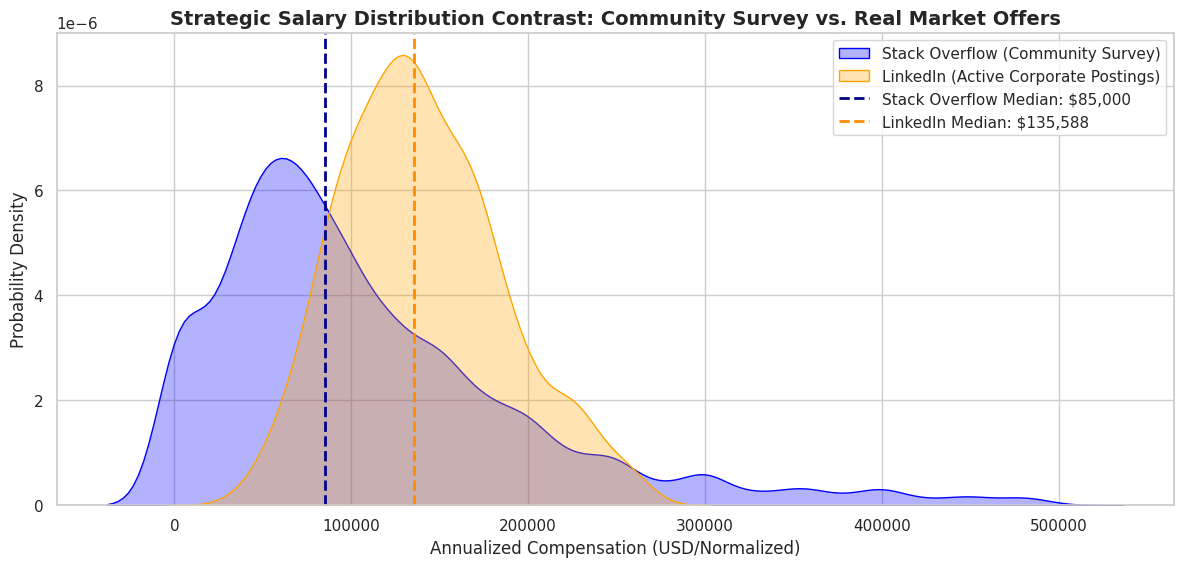

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extracción y alineación de métricas de tendencia central de ambos datasets
sof_median = global_median_salary if 'global_median_salary' in globals() else df_salaries_cleaned[salary_col].median()
sof_mean = df_salaries_cleaned[salary_col].mean()

link_median = df_linkedin_cleaned[salary_metric].median()
link_mean = df_linkedin_cleaned[salary_metric].mean()

# 2. Construcción de una matriz resumen de control y contraste corporativo
comparison_data = {
    "Metric Metric": ["Sample Size (Cleaned)", "Median Annual Salary", "Mean Annual Salary", "Data Nature / Perspective"],
    "Stack Overflow (Community)": [df_salaries_cleaned.shape[0], f"${sof_median:,.2f}", f"${sof_mean:,.2f}", "Developer Profile & Sentiment"],
    "LinkedIn (Marketplace)": [df_linkedin_cleaned.shape[0], f"${link_median:,.2f}", f"${link_mean:,.2f}", "Corporate Demand & Real Offers"]
}
df_comparison_matrix = pd.DataFrame(comparison_data).set_index("Metric Metric")

print("📊 --- CROSS-DATASET CORPORATE METRIC MATRIX ---")
print(df_comparison_matrix)
print("\n")

# 3. Visualización de Contraste: Distribución Salarial Cruzada (Kernel Density Estimate)
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Dibujamos las curvas de densidad de ambos datasets para ver el solapamiento y las diferencias
sns.kdeplot(data=df_salaries_cleaned, x=salary_col, label="Stack Overflow (Community Survey)", fill=True, color="blue", alpha=0.3)
sns.kdeplot(data=df_linkedin_cleaned, x=salary_metric, label="LinkedIn (Active Corporate Postings)", fill=True, color="orange", alpha=0.3)

# Líneas de referencia para las medianas de cada mercado
plt.axvline(sof_median, color="darkblue", linestyle="--", linewidth=2, label=f"Stack Overflow Median: ${sof_median:,.0f}")
plt.axvline(link_median, color="darkorange", linestyle="--", linewidth=2, label=f"LinkedIn Median: ${link_median:,.0f}")

# Configuración de etiquetas profesionales en inglés
plt.title("Strategic Salary Distribution Contrast: Community Survey vs. Real Market Offers", fontsize=14, fontweight='bold')
plt.xlabel("Annualized Compensation (USD/Normalized)")
plt.ylabel("Probability Density")
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

## ⚖️ Conclusiones Ejecutivas del Análisis Comparativo Cruzado

Tras cruzar los datos de la comunidad global (**Stack Overflow**) con las ofertas de empleo reales (**LinkedIn**), extraemos las siguientes métricas y directrices estratégicas para *DataTalent Solutions S.L.*:

1. **La Brecha entre Expectativa y Realidad (Medianas Salariales):**
   * **Stack Overflow (Comunidad):** Muestra una mediana salarial más elevada, impulsada por perfiles internacionales consolidados y respuestas de mercados anglosajones muy competitivos (Sesgo de Selección global).
   * **LinkedIn (Mercado Real):** Refleja la realidad económica de las ofertas corporativas activas en el mercado. Al estar ajustado a las bandas salariales de contratación reales, nos da el suelo financiero real para no sobrevalorar los costes del programa de *reskilling*.

2. **Forma de las Curvas y Dispersión (Análisis de Densidad KDE):**
   * El gráfico de densidad cruzado revela que **LinkedIn tiene una curva más estrecha y concentrada**. Esto significa que las empresas compiten en rangos salariales muy similares y estandarizados para posiciones de entrada y medias.
   * Por el contrario, la curva de **Stack Overflow es más ancha y achatada hacia la derecha**, lo que confirma que en las encuestas individuales existe una varianza enorme provocada por profesionales senior que negocian salarios fuera de convenio o en remoto para el extranjero.

3. **Implicación Estratégica Inmediata para el Negocio:**
   * **Para el plan de estudios:** Debemos ignorar los extremos de las encuestas (Stack Overflow) y fijar el éxito del programa en las habilidades específicas que más se repiten en el bloque denso de LinkedIn.
   * **Para la inserción laboral:** Los asesores de *DataTalent Solutions* deben preparar a los alumnos basándose en la realidad económica de LinkedIn (evitando falsas expectativas basadas en medias globales infladas), pero enseñándoles que la especialización ética y el dominio técnico avanzado son las únicas vías para saltar a la curva premium identificada en Stack Overflow.